# 🌌 ExoProfiler — Comprensión inicial del dataset

## 1. Data Understanding

Este notebook tiene como objetivo realizar una primera exploración del dataset de exoplanetas utilizado en el proyecto ExoProfiler.

En esta fase se analizarán:

- Las dimensiones del dataset.
- La estructura y significado de las variables.
- Los tipos de datos.
- La presencia de valores nulos.
- La existencia de registros duplicados.
- La relevancia inicial de las variables para el análisis de clustering.

El objetivo final es comprender la calidad y estructura de los datos antes de realizar el análisis exploratorio y el preprocesamiento.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
DATA_PATH = "../data/raw/exoplanets.csv"

df = pd.read_csv(
    DATA_PATH,
    comment="#" #Ignora las líneas que comiencen por #, porque son comentarios/metadatos y no forman parte de la tabla.
)

df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,pl_refname,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_radj,pl_radjerr1,pl_radjerr2,pl_radjlim,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_bmasselim,pl_bmassj,pl_bmassjerr1,pl_bmassjerr2,pl_bmassjlim,pl_bmassprov,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_insol,pl_insolerr1,pl_insolerr2,pl_insollim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,ttv_flag,st_refname,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_mass,st_masserr1,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_metratio,st_logg,st_loggerr1,st_loggerr2,st_logglim,sy_refname,rastr,ra,decstr,dec,sy_dist,sy_disterr1,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,AU Mic b,AU Mic,1,1,4,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,8.463446,0.000005,-0.000005,0.0,0.0700,0.0060,-0.0070,0.0,4.79,0.29,-0.29,0.0,0.427336,0.025872,-0.025872,0.0,8.99,2.61,-2.67,0.0,0.028286,0.008212,-0.008401,0.0,Mass,0.070,0.0900,-0.040,0.0,NaN,NaN,NaN,NaN,554.8,31.6,-32.0,0.0,1.0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,M1 V,3540.0,120.0,-110.0,0.0,0.862,0.052,-0.052,0.0,0.635,0.04,-0.07,0.0,0.01,0.06,-0.06,0.0,[Fe/H],4.37,0.08,-0.10,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,20h45m09.87s,311.291137,-31d20m32.82s,-31.342450,9.7221,0.004625,-0.004625,8.810,0.100,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2026-03-05,2024-09,2026-03-05
1,AU Mic c,AU Mic,1,1,4,Transit,2021,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,18.859023,0.000022,-0.000024,0.0,0.1190,0.0110,-0.0110,0.0,2.79,0.18,-0.17,0.0,0.248908,0.016059,-0.015166,0.0,14.46,3.24,-3.42,0.0,0.045496,0.010194,-0.010761,0.0,Mass,0.180,0.0800,-0.070,0.0,NaN,NaN,NaN,NaN,424.7,24.2,-24.5,0.0,1.0,<a refstr=MALLORQUIN_ET_AL_2024 href=https://u...,M1 V,3540.0,120.0,-110.0,0.0,0.862,0.052,-0.052,0.0,0.635,0.04,-0.07,0.0,0.01,0.06,-0.06,0.0,[Fe/H],4.37,0.08,-0.10,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,20h45m09.87s,311.291137,-31d20m32.82s,-31.342450,9.7221,0.004625,-0.004625,8.810,0.100,-0.100,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,2026-03-05,2024-09,2026-03-05
2,BD+05 4868 A b,BD+05 4868 A,1,2,1,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=HON_ET_AL_2025 href=https://ui.adsab...,1.271869,0.000001,-0.000001,0.0,0.0208,0.0003,-0.0003,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.20,NaN,NaN,1.0,0.019507,NaN,NaN,1.0,Mass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1820.0,45.0,-45.0,0.0,0.0,<a refstr=HON_ET_AL_2025 href=https://ui.adsab...,K V,4596.0,65.0,-64.0,0.0,0.690,0.020,-0.020,0.0,0.700,0.02,-0.02,0.0,-0.05,0.08,-0.05,0.0,[Fe/H],4.60,0.03,-0.02,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,21h47m26.74s,326.861404,+06d36m19.15s,6.605319,43.5687,0.097500,-0.097100,10.158,0.010,-0.010,7.448,0.026,-0.026,9.84152,0.000476,-0.000476,2025-03-21,2025-05,2025-03-21
3,BD-14 3065 b,BD-14 3065 A,1,3,1,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,<a refstr=SUBJAK_ET_AL_2024 href=https://ui.ad...,4.288973,0.000005,-0.000005,0.0,0.0656,0.0026,-0.0026,0.0,21.59,1.05,-1.05,0.0,1.926000,0.094000,-0.094000,0.0,3932.00,290.00,-280.00,0.0,12.370000,0.920000,-0.870000,0.0,Mass,0.066,0.0098,-0.011,0.0,NaN,NaN,NaN,NaN,2001.0,31.0,-31.0,0.0,0.0,<a refstr=SUBJAK_ET_AL_2024 href=https://ui.ad...,NaN,6935.0,90.0,-90.0,0.0,2.350,0.080,-0.080,0.0,1.410,0.05,-0.05,0.0,-0.34,0.05,-0.05,0.0,[Fe/H],3.85,0.03,-0.03,0.0,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,10h14m40.72s,153.669669,-15d38m34.21s,-15.642837,58

In [4]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 910
Número de columnas: 92


In [5]:
df.columns.tolist()

['pl_name',
 'hostname',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'discoverymethod',
 'disc_year',
 'disc_facility',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_orbeccen',
 'pl_orbeccenerr1',
 'pl_orbeccenerr2',
 'pl_orbeccenlim',
 'pl_insol',
 'pl_insolerr1',
 'pl_insolerr2',
 'pl_insollim',
 'pl_eqt',
 'pl_eqterr1',
 'pl_eqterr2',
 'pl_eqtlim',
 'ttv_flag',
 'st_refname',
 'st_spectype',
 'st_teff',
 'st_tefferr1',
 'st_tefferr2',
 'st_tefflim',
 'st_rad',
 'st_raderr1',
 'st_raderr2',
 'st_radlim',
 'st_mass',
 'st_masserr1',
 'st_masserr2',
 'st_masslim',
 'st_met',
 'st_me

## 2. Estructura de las variables

El dataset contiene información de diferentes niveles relacionados con cada exoplaneta.

Los nombres de las variables utilizan prefijos que permiten identificar el tipo de información:

- `pl_`: propiedades del planeta.
- `st_`: propiedades de la estrella anfitriona.
- `sy_`: propiedades generales del sistema planetario.
- `disc_`: información relacionada con el descubrimiento.

Además, algunas variables incluyen sufijos relacionados con errores de medición, límites o referencias bibliográficas.

Estas variables deberán analizarse cuidadosamente antes de seleccionar las características utilizadas para clustering.

In [6]:
#Inventario de columnas
column_info = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (
        df.isnull().mean().values * 100
    ).round(2),
    "valores_unicos": df.nunique().values
})

column_info

,variable,dtype,nulos,porcentaje_nulos,valores_unicos
0,pl_name,str,0,0.00,910
1,hostname,str,0,0.00,765
2,default_flag,int64,0,0.00,1
3,sy_snum,int64,0,0.00,3
4,sy_pnum,int64,0,0.00,6
5,discoverymethod,str,0,0.00,2
6,disc_year,int64,0,0.00,9
7,disc_facility,str,0,0.00,1
8,soltype,str,0,0.00,2
9,pl_controv_flag,int64,0,0.00,2


In [7]:
#Nulos

column_info.sort_values(
    by="porcentaje_nulos",
    ascending=False
).head(30)

,variable,dtype,nulos,porcentaje_nulos,valores_unicos
50,st_spectype,str,560,61.54,116
38,pl_orbeccenerr2,float64,555,60.99,117
37,pl_orbeccenerr1,float64,555,60.99,133
41,pl_insolerr1,float64,539,59.23,238
42,pl_insolerr2,float64,539,59.23,228
43,pl_insollim,float64,524,57.58,1
40,pl_insol,float64,524,57.58,374
28,pl_bmasseerr1,float64,342,37.58,298
33,pl_bmassjerr2,float64,342,37.58,293
29,pl_bmasseerr2,float64,342,37.58,288


In [8]:
#Duplicados

duplicados = df.duplicated().sum()

print(f"Filas duplicadas completas: {duplicados}")

Filas duplicadas completas: 0


In [12]:
#¿Tenemos exactamente una fila por planeta?

df["pl_name"].nunique()

910

In [13]:
df["pl_name"].value_counts().head(20)

pl_name
AU Mic b          1
AU Mic c          1
BD+05 4868 A b    1
BD-14 3065 b      1
DS Tuc A b        1
GJ 1252 b         1
GJ 143 b          1
GJ 238 b          1
GJ 3090 b         1
GJ 341 b          1
GJ 3473 b         1
GJ 357 b          1
GJ 367 b          1
GJ 3929 b         1
GJ 806 b          1
Gliese 12 b       1
HD 101581 b       1
HD 101581 c       1
HD 108236 b       1
HD 108236 c       1
Name: count, dtype: int64

In [14]:
#Tipos de variables

df.dtypes.value_counts()

float64    71
str        16
int64       5
Name: count, dtype: int64

In [15]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print(f"Variables numéricas: {len(numeric_cols)}")
print(f"Variables no numéricas: {len(categorical_cols)}")

Variables numéricas: 76
Variables no numéricas: 16


## 3. Selección conceptual inicial de variables

El dataset original contiene un gran número de variables que representan distintos tipos de información: propiedades físicas de los planetas, características orbitales, datos de las estrellas anfitrionas, información sobre el descubrimiento, referencias bibliográficas e incertidumbres asociadas a las mediciones.

Para un modelo de clustering no es conveniente utilizar automáticamente todas las columnas disponibles. Las variables utilizadas deben estar relacionadas con el fenómeno que se quiere estudiar, ya que los algoritmos de clustering agrupan las observaciones en función de la similitud entre sus características.

En este proyecto buscamos descubrir posibles **familias de exoplanetas según sus características físicas, orbitales y su entorno estelar**.

Por este motivo, se realiza primero una selección conceptual de variables potencialmente relevantes.

Esta selección es únicamente preliminar. Las variables candidatas serán posteriormente evaluadas mediante el análisis exploratorio de datos (EDA), teniendo en cuenta:

- Su significado científico.
- La cantidad de valores disponibles.
- La presencia de valores nulos.
- Sus distribuciones.
- La existencia de valores extremos.
- La posible redundancia o correlación con otras variables.

La selección definitiva de características se realizará después de este análisis.

### 3.1 Variables candidatas según su significado

Se han identificado inicialmente dos grupos de variables potencialmente relevantes:

1. **Variables planetarias y orbitales:** describen directamente las propiedades físicas y orbitales del exoplaneta.

2. **Variables estelares:** describen características de la estrella anfitriona y permiten estudiar si el entorno estelar aporta información relevante a la formación de los grupos.

Estas variables se consideran **candidatas**, no variables definitivas del modelo.

Su inclusión final dependerá de los resultados obtenidos durante el análisis exploratorio.

In [16]:
# Variables relacionadas directamente con las propiedades
# físicas y orbitales de los exoplanetas.
planet_features = [
    "pl_orbper",      # Periodo orbital del planeta (días).
    "pl_orbsmax",     # Semieje mayor: distancia orbital respecto a su estrella (UA).
    "pl_rade",        # Radio del planeta expresado en radios terrestres.
    "pl_bmasse",      # Masa del planeta expresada en masas terrestres.
    "pl_orbeccen",    # Excentricidad: indica cómo de circular o elíptica es la órbita.
    "pl_insol",       # Insolación recibida respecto a la que recibe la Tierra.
    "pl_eqt"          # Temperatura de equilibrio estimada del planeta (K).
]

# Variables relacionadas con las propiedades físicas
# de la estrella anfitriona del planeta.
stellar_features = [
    "st_teff",        # Temperatura efectiva de la estrella (K).
    "st_rad",         # Radio de la estrella respecto al radio del Sol.
    "st_mass",        # Masa de la estrella respecto a la masa del Sol.
    "st_met",         # Metalicidad de la estrella.
    "st_logg"         # Gravedad superficial de la estrella.
]

# Unimos ambos grupos para poder analizarlos conjuntamente.
candidate_features = planet_features + stellar_features

# Mostramos el número total de variables candidatas.
print(f"Número inicial de variables candidatas: {len(candidate_features)}")

# Mostramos sus nombres para comprobar que la selección es correcta.
candidate_features

Número inicial de variables candidatas: 12


['pl_orbper',
 'pl_orbsmax',
 'pl_rade',
 'pl_bmasse',
 'pl_orbeccen',
 'pl_insol',
 'pl_eqt',
 'st_teff',
 'st_rad',
 'st_mass',
 'st_met',
 'st_logg']

### 3.2 Comprobación de las variables seleccionadas

Antes de continuar con el análisis se comprueba que todas las variables candidatas existen realmente en el dataset.

Esta validación evita errores posteriores provocados por nombres incorrectos o columnas inexistentes y permite verificar que la selección conceptual coincide con la estructura real de los datos.

In [17]:
# Buscamos si alguna de las variables candidatas
# no está presente entre las columnas del dataset.
missing_features = [
    column
    for column in candidate_features
    if column not in df.columns
]

# Si la lista está vacía, significa que todas las variables existen.
if not missing_features:
    print("Todas las variables candidatas existen en el dataset.")
else:
    print("Variables no encontradas:")
    print(missing_features)

Todas las variables candidatas existen en el dataset.


## 4. Análisis de disponibilidad y valores nulos

Una variable puede ser relevante desde el punto de vista científico, pero su utilidad para el clustering también depende de la cantidad de observaciones disponibles.

Los algoritmos de clustering utilizados posteriormente requieren trabajar con datos numéricos completos, por lo que es necesario estudiar la presencia de valores ausentes antes de seleccionar las características definitivas.

En esta fase no se eliminarán ni imputarán valores nulos.

El objetivo es únicamente analizar su distribución y determinar qué variables presentan una cobertura suficiente y cuáles requieren una estrategia específica de tratamiento.

In [18]:
# Calculamos el número total de observaciones del dataset.
total_rows = len(df)

# Creamos una tabla resumen para estudiar la disponibilidad
# de datos de cada variable candidata.
candidate_summary = pd.DataFrame({
    
    # Tipo de dato almacenado en cada variable.
    "tipo_dato": df[candidate_features].dtypes,
    
    # Número de valores disponibles (no nulos).
    "valores_disponibles": df[candidate_features].notna().sum(),
    
    # Número de valores ausentes.
    "nulos": df[candidate_features].isna().sum(),
    
    # Porcentaje de valores ausentes respecto al total.
    "porcentaje_nulos": (
        df[candidate_features].isna().mean() * 100
    ).round(2),
    
    # Porcentaje de observaciones que sí contienen información.
    "cobertura": (
        df[candidate_features].notna().mean() * 100
    ).round(2)
})

# Ordenamos las variables desde la que tiene mayor cobertura
# hasta la que presenta más información ausente.
candidate_summary = candidate_summary.sort_values(
    by="cobertura",
    ascending=False
)

candidate_summary

,tipo_dato,valores_disponibles,nulos,porcentaje_nulos,cobertura
pl_orbper,float64,907,3,0.33,99.67
st_rad,float64,905,5,0.55,99.45
pl_rade,float64,897,13,1.43,98.57
st_teff,float64,885,25,2.75,97.25
st_logg,float64,821,89,9.78,90.22
st_mass,float64,787,123,13.52,86.48
pl_orbsmax,float64,704,206,22.64,77.36
st_met,float64,685,225,24.73,75.27
pl_eqt,float64,670,240,26.37,73.63
pl_orbeccen,float64,623,287,31.54,68.46


### 4.1 Visualización de la cobertura de las variables candidatas

Se representa gráficamente el porcentaje de datos disponibles para cada variable candidata.

Esta visualización permite identificar rápidamente qué características presentan una buena cobertura y cuáles podrían limitar significativamente el número de planetas disponibles para el análisis.

Una baja cobertura no implica automáticamente que una variable deba eliminarse. Su relevancia científica y las posibles estrategias de tratamiento deberán evaluarse antes de tomar una decisión definitiva.

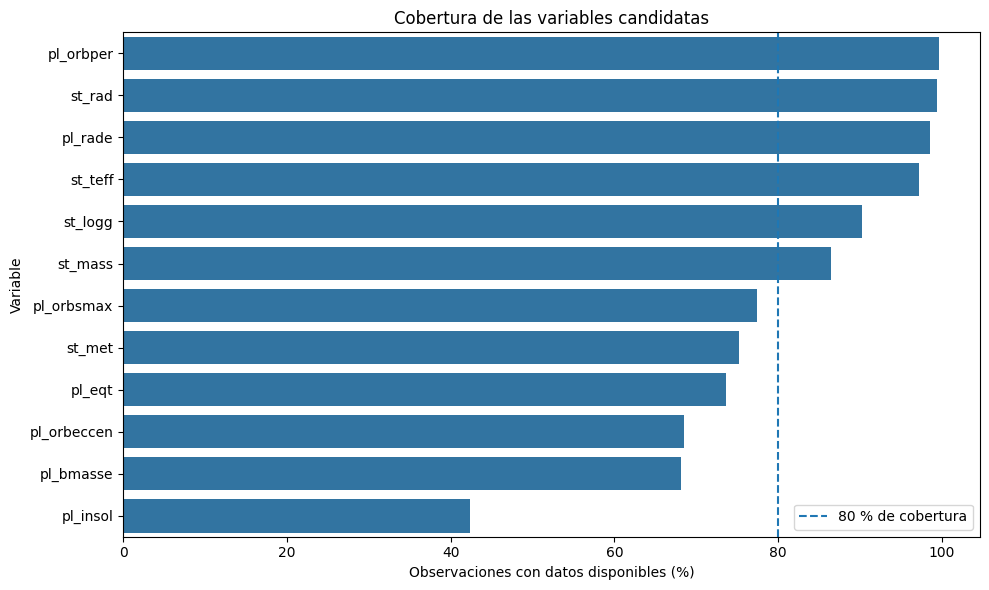

In [19]:
# Creamos una figura con un tamaño suficiente para
# visualizar claramente todas las variables.
plt.figure(figsize=(10, 6))

# Representamos el porcentaje de cobertura de cada variable.
sns.barplot(
    data=candidate_summary.reset_index(),
    x="cobertura",
    y="index"
)

# Añadimos una línea de referencia en el 80 %.
# No representa un criterio automático de eliminación,
# sino una ayuda visual para interpretar la disponibilidad.
plt.axvline(
    x=80,
    linestyle="--",
    label="80 % de cobertura"
)

# Añadimos títulos descriptivos.
plt.title("Cobertura de las variables candidatas")
plt.xlabel("Observaciones con datos disponibles (%)")
plt.ylabel("Variable")

# Mostramos la leyenda y el gráfico.
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Disponibilidad conjunta de las variables

Además de estudiar los valores nulos de cada variable individualmente, es necesario conocer cuántos exoplanetas disponen simultáneamente de información completa para todas las características candidatas.

Este análisis es especialmente importante para clustering, ya que eliminar todas las filas que contienen algún valor nulo podría reducir considerablemente el tamaño del dataset y provocar una pérdida importante de información.

Por este motivo, antes de decidir cualquier estrategia de tratamiento se analiza el impacto que tendría trabajar únicamente con casos completos.

In [20]:
# Seleccionamos únicamente las variables candidatas
# y eliminamos temporalmente las filas que contienen
# al menos un valor nulo.
complete_cases = df[candidate_features].dropna()

# Calculamos cuántos planetas conservaríamos.
n_complete = len(complete_cases)

# Calculamos qué porcentaje representan respecto al dataset original.
percentage_complete = (n_complete / len(df)) * 100

print(f"Planetas totales: {len(df)}")
print(f"Planetas con todas las variables disponibles: {n_complete}")
print(
    f"Porcentaje conservado: "
    f"{percentage_complete:.2f} %"
)

Planetas totales: 910
Planetas con todas las variables disponibles: 249
Porcentaje conservado: 27.36 %


### Conclusión provisional sobre los valores ausentes

El análisis de cobertura permite comprobar que las variables candidatas presentan distintos niveles de disponibilidad.

No se aplicará todavía ninguna estrategia de eliminación o imputación, ya que hacerlo en esta fase podría provocar una pérdida innecesaria de información o introducir valores artificiales que afecten a las distancias utilizadas posteriormente por los algoritmos de clustering.

En las siguientes etapas del EDA se analizarán conjuntamente:

- La relevancia científica de cada variable.
- Su porcentaje de cobertura.
- Su distribución.
- La presencia de valores extremos.
- Su relación y posible redundancia con otras características.

A partir de estos resultados se decidirá qué variables conservar y qué estrategia de tratamiento aplicar.

### 4.3 Impacto acumulado de los valores nulos

El análisis anterior muestra que únicamente 249 de los 910 exoplanetas disponen de información completa para las 12 variables candidatas, lo que representa un 27,36 % del dataset original.

Eliminar directamente todas las observaciones con algún valor ausente supondría perder más del 70 % de los planetas disponibles.

Para comprender mejor esta pérdida de información, se analiza cómo disminuye progresivamente el número de observaciones completas al incorporar variables con menor cobertura.

Este análisis permitirá identificar qué características reducen especialmente el tamaño de la muestra y ayudará posteriormente a encontrar un equilibrio entre:

- La cantidad de exoplanetas disponibles.
- La riqueza de información utilizada para describirlos.
- La relevancia científica de las variables.

Este análisis no determina automáticamente qué variables deben eliminarse, sino que sirve como apoyo para la selección posterior de características.

In [21]:
# Obtenemos las variables candidatas ordenadas
# desde la que tiene mayor cobertura hasta la que tiene menor cobertura.
features_by_coverage = candidate_summary.index.tolist()

# Creamos una lista vacía donde guardaremos
# los resultados del análisis acumulativo.
coverage_impact = []

# Esta lista irá almacenando progresivamente
# las variables que incorporamos al análisis.
selected_features = []

# Recorremos las variables una a una siguiendo
# el orden de mayor a menor cobertura.
for feature in features_by_coverage:
    
    # Añadimos la nueva variable al conjunto analizado.
    selected_features.append(feature)
    
    # Contamos cuántos planetas tienen datos completos
    # para TODAS las variables incluidas hasta este momento.
    complete_rows = df[selected_features].dropna().shape[0]
    
    # Calculamos qué porcentaje del dataset original conservaríamos.
    retained_percentage = (complete_rows / len(df)) * 100
    
    # Guardamos los resultados de esta iteración.
    coverage_impact.append({
        "variable_añadida": feature,
        "numero_variables": len(selected_features),
        "planetas_disponibles": complete_rows,
        "porcentaje_conservado": round(retained_percentage, 2)
    })

# Convertimos los resultados en un DataFrame
# para poder analizarlos fácilmente.
coverage_impact_df = pd.DataFrame(coverage_impact)

coverage_impact_df

,variable_añadida,numero_variables,planetas_disponibles,porcentaje_conservado
0,pl_orbper,1,907,99.67
1,st_rad,2,905,99.45
2,pl_rade,3,894,98.24
3,st_teff,4,874,96.04
4,st_logg,5,811,89.12
5,st_mass,6,695,76.37
6,pl_orbsmax,7,627,68.90
7,st_met,8,602,66.15
8,pl_eqt,9,558,61.32
9,pl_orbeccen,10,485,53.30


#### Evolución del número de observaciones completas

El siguiente gráfico muestra cómo cambia el número de exoplanetas disponibles a medida que se incorporan progresivamente variables con menor cobertura.

Una reducción pronunciada tras añadir una determinada característica indica que esa variable limita especialmente el número de observaciones completas disponibles.

Sin embargo, esta pérdida de datos deberá valorarse conjuntamente con la relevancia científica de la variable antes de decidir su inclusión o exclusión.

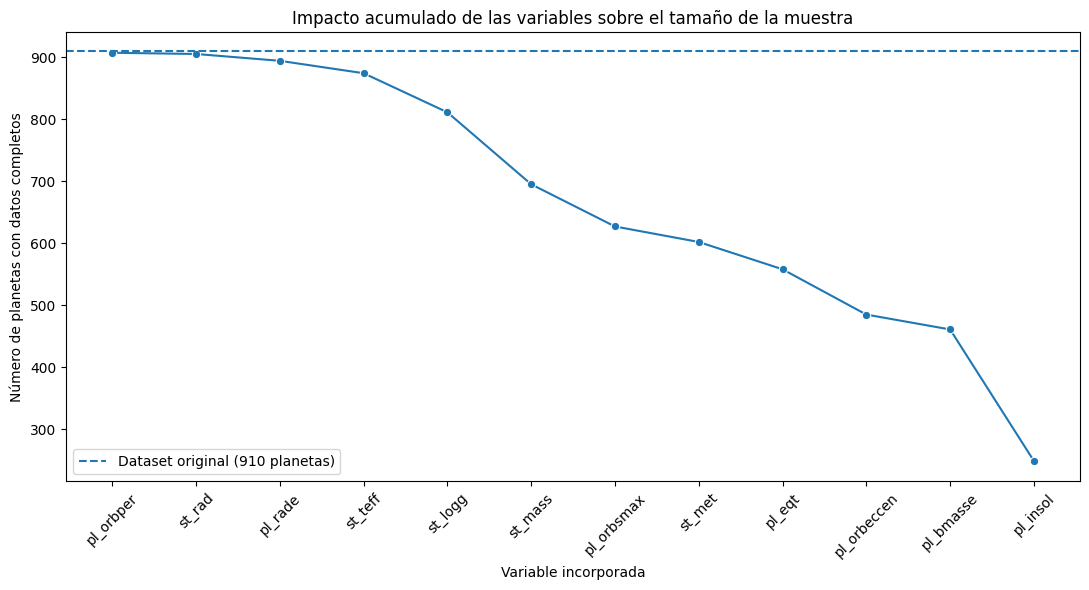

In [22]:
# Creamos una figura para visualizar cómo disminuye
# el número de planetas disponibles al añadir variables.
plt.figure(figsize=(11, 6))

# Dibujamos una línea que relaciona cada variable añadida
# con el número de observaciones completas que se conservan.
sns.lineplot(
    data=coverage_impact_df,
    x="variable_añadida",
    y="planetas_disponibles",
    marker="o"
)

# Añadimos una línea horizontal que representa
# el número total de planetas del dataset original.
plt.axhline(
    y=len(df),
    linestyle="--",
    label=f"Dataset original ({len(df)} planetas)"
)

# Añadimos títulos descriptivos.
plt.title(
    "Impacto acumulado de las variables sobre el tamaño de la muestra"
)
plt.xlabel("Variable incorporada")
plt.ylabel("Número de planetas con datos completos")

# Giramos los nombres de las variables para facilitar su lectura.
plt.xticks(rotation=45)

# Mostramos la leyenda.
plt.legend()

# Ajustamos automáticamente los elementos del gráfico.
plt.tight_layout()

# Mostramos el resultado.
plt.show()

In [23]:
# Calculamos cuántos planetas se pierden al incorporar
# cada nueva variable respecto al paso anterior.
coverage_impact_df["planetas_perdidos"] = (
    coverage_impact_df["planetas_disponibles"]
    .shift(1, fill_value=len(df))
    - coverage_impact_df["planetas_disponibles"]
)

coverage_impact_df

,variable_añadida,numero_variables,planetas_disponibles,porcentaje_conservado,planetas_perdidos
0,pl_orbper,1,907,99.67,3
1,st_rad,2,905,99.45,2
2,pl_rade,3,894,98.24,11
3,st_teff,4,874,96.04,20
4,st_logg,5,811,89.12,63
5,st_mass,6,695,76.37,116
6,pl_orbsmax,7,627,68.90,68
7,st_met,8,602,66.15,25
8,pl_eqt,9,558,61.32,44
9,pl_orbeccen,10,485,53.30,73


### Conclusión provisional sobre la disponibilidad de datos

El dataset contiene 910 exoplanetas, pero la disponibilidad de información varía considerablemente entre las características analizadas.

Variables como `pl_orbper`, `st_rad`, `pl_rade` y `st_teff` presentan una cobertura superior al 97 %, mientras que otras características científicamente relevantes tienen una disponibilidad significativamente menor.

El caso más destacado es `pl_insol`, para la que solo se dispone de información en el 42,42 % de las observaciones.

Al exigir datos completos simultáneamente para las 12 variables candidatas, el conjunto disponible se reduce a 249 exoplanetas, lo que representa únicamente el 27,36 % del dataset original.

Por tanto, eliminar directamente todas las filas con valores ausentes supondría perder aproximadamente el 72,64 % de las observaciones.

Estos resultados muestran la necesidad de estudiar cuidadosamente la selección de características y el tratamiento de los valores ausentes antes del modelado.

La decisión final no se basará únicamente en el porcentaje de nulos, sino también en la relevancia científica de cada variable, su distribución, su relación con otras características y la información adicional que pueda aportar al proceso de clustering.

## 5. Análisis de las distribuciones

Una vez estudiada la disponibilidad de los datos, se analiza cómo se distribuyen los valores de las variables candidatas.

El estudio de las distribuciones permite detectar:

- Variables aproximadamente simétricas o fuertemente sesgadas.
- Diferencias importantes de escala.
- Concentraciones de observaciones en determinados rangos.
- Posibles valores extremos.
- Variables que podrían requerir transformaciones antes del clustering.

Este análisis es especialmente relevante porque algoritmos como K-Means utilizan distancias entre observaciones. Por tanto, la escala y distribución de las variables pueden influir considerablemente en la formación de los clusters.

En primer lugar se analizarán las variables relacionadas directamente con las propiedades físicas y orbitales de los exoplanetas.

### 5.1 Estadísticos descriptivos de las variables planetarias

Se calculan los principales estadísticos descriptivos de las variables planetarias candidatas.

Estos valores permiten conocer su tendencia central, dispersión y rango antes de analizar gráficamente sus distribuciones.

Se prestará especial atención a las diferencias entre la media y la mediana, así como a valores máximos muy alejados de los percentiles centrales, ya que pueden ser indicios de distribuciones asimétricas o de observaciones extremas.

In [24]:
# Calculamos los principales estadísticos descriptivos
# únicamente para las variables planetarias candidatas.
planet_descriptive = df[planet_features].describe().T

# Añadimos la mediana de forma explícita para facilitar
# su comparación con la media de cada variable.
planet_descriptive["median"] = df[planet_features].median()

# Seleccionamos y ordenamos los estadísticos
# más útiles para nuestra exploración.
planet_descriptive = planet_descriptive[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

planet_descriptive

,count,mean,median,std,min,25%,50%,75%,max
pl_orbper,907.0,16.796365,5.705880,100.204849,0.238182,3.347239,5.705880,11.514239,2890.000000
pl_orbsmax,704.0,0.100049,0.060040,0.197219,0.005626,0.037950,0.060040,0.105550,4.370000
pl_rade,897.0,5.923743,3.181755,4.960706,0.566000,2.265000,3.181755,10.500000,25.000000
pl_bmasse,620.0,337.292291,30.150000,926.820013,0.460000,7.700000,30.150000,255.851868,8899.195396
pl_orbeccen,623.0,0.106061,0.046000,0.152365,0.000000,0.000000,0.046000,0.150000,0.941200
pl_insol,386.0,383.054285,74.185000,672.777170,0.181000,18.670750,74.185000,557.000000,5300.000000
pl_eqt,670.0,965.632448,862.745000,476.450705,163.000000,596.000000,862.745000,1294.250000,3646.000000


### 5.2 Histogramas de las variables planetarias

Se utilizan histogramas para visualizar la distribución de cada característica planetaria.

Cada barra representa el número de exoplanetas cuyos valores se encuentran dentro de un determinado intervalo.

El objetivo es identificar posibles asimetrías, concentraciones de datos y colas extremas que puedan influir posteriormente en los algoritmos de clustering.

Los valores nulos se excluyen únicamente de cada visualización, sin modificar el dataset original.

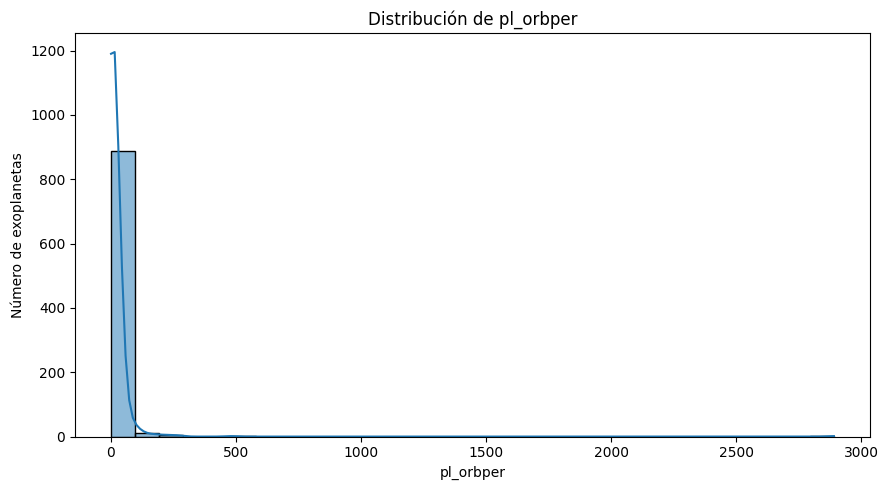

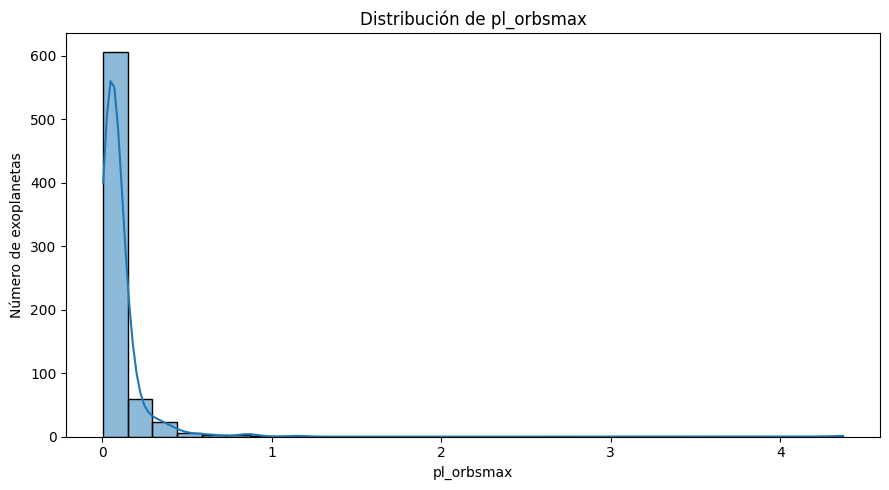

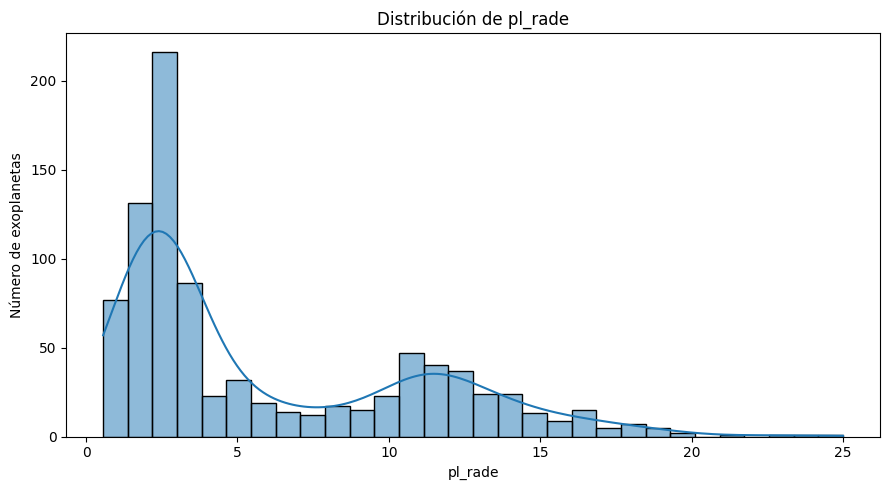

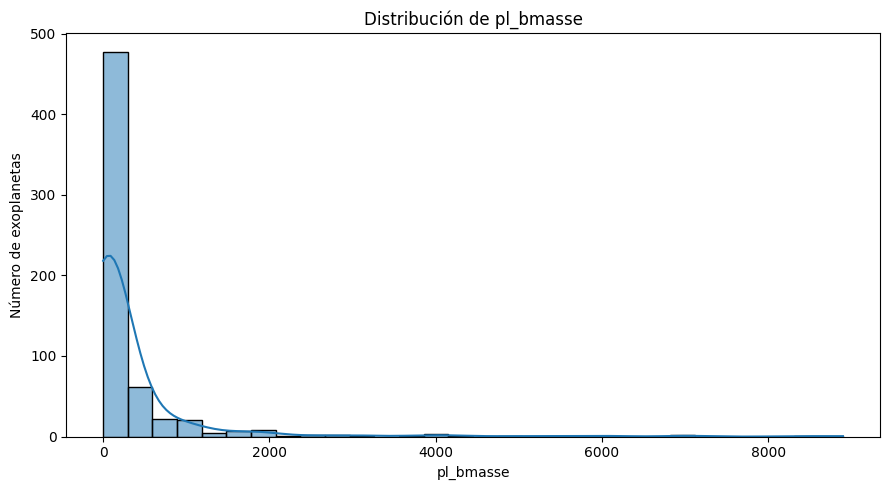

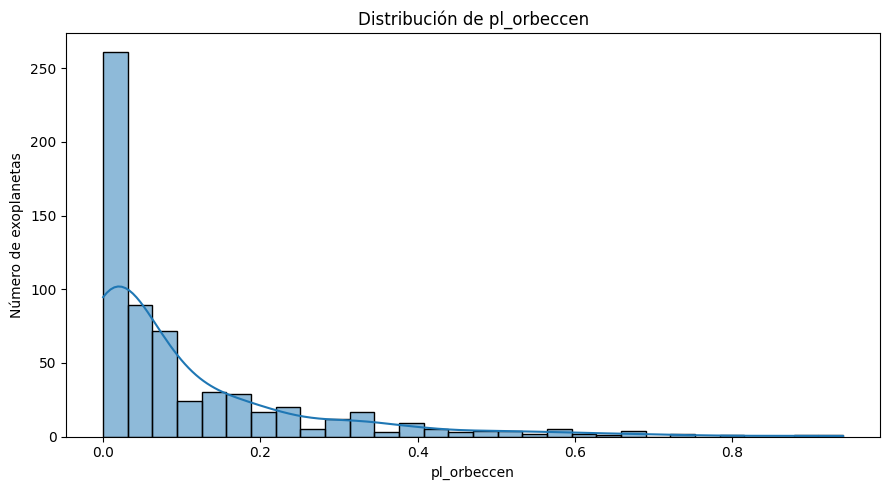

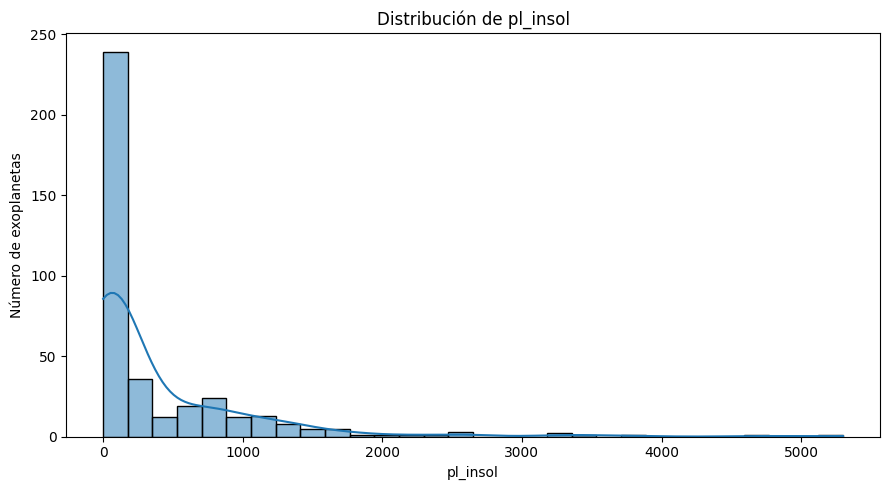

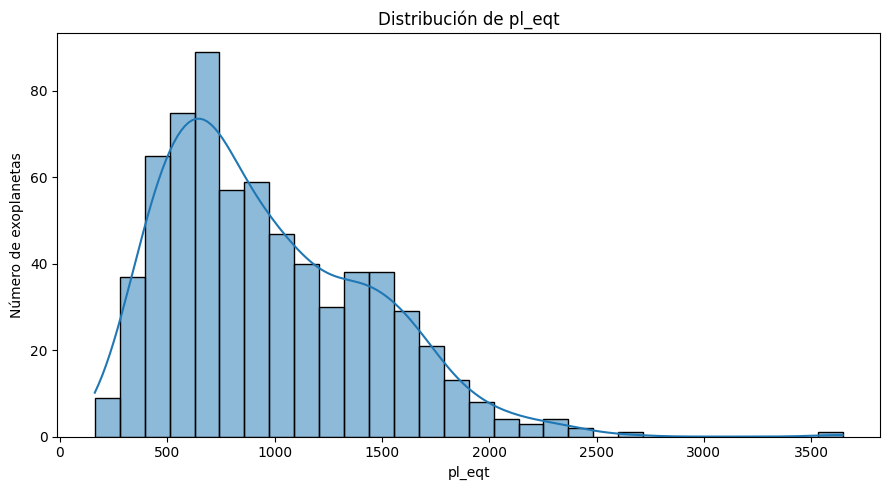

In [25]:
# Recorremos cada una de las variables planetarias
# para estudiar su distribución individualmente.
for feature in planet_features:

    # Creamos una figura independiente para cada variable.
    plt.figure(figsize=(9, 5))

    # Eliminamos únicamente los valores nulos de la variable
    # que estamos representando para que no interfieran
    # en la construcción del histograma.
    data = df[feature].dropna()

    # Creamos el histograma.
    # kde=True añade una curva suavizada que ayuda
    # a visualizar la forma general de la distribución.
    sns.histplot(
        data=data,
        bins=30,
        kde=True
    )

    # Añadimos un título indicando la variable analizada.
    plt.title(
        f"Distribución de {feature}"
    )

    # Etiquetamos los ejes.
    plt.xlabel(feature)
    plt.ylabel("Número de exoplanetas")

    # Ajustamos el diseño para evitar solapamientos.
    plt.tight_layout()

    # Mostramos el gráfico.
    plt.show()

### 5.3 Interpretación inicial de las distribuciones planetarias

El análisis de las distribuciones muestra comportamientos considerablemente diferentes entre las características planetarias.

Las variables `pl_orbper`, `pl_orbsmax`, `pl_bmasse`, `pl_orbeccen` y `pl_insol` presentan distribuciones claramente asimétricas hacia la derecha. La mayoría de las observaciones se concentra en valores relativamente bajos, mientras que un número reducido de exoplanetas alcanza valores considerablemente superiores.

Estas diferencias son especialmente visibles al comparar la media y la mediana. Por ejemplo, en `pl_bmasse` la media es aproximadamente 337 masas terrestres, mientras que la mediana se sitúa alrededor de 30, lo que evidencia la influencia de valores extremadamente elevados.

Estos valores no deben considerarse automáticamente errores o eliminarse como outliers, ya que pueden representar objetos astronómicos reales con características poco frecuentes.

La variable `pl_rade` presenta un comportamiento especialmente interesante, con diferentes concentraciones visibles en determinados rangos de radio. Esto podría indicar la existencia de distintas poblaciones según el tamaño planetario, aunque será necesario estudiar esta estructura conjuntamente con otras variables antes de realizar cualquier interpretación como familia planetaria.

Por su parte, `pl_eqt` presenta una distribución menos extrema, aunque mantiene cierta asimetría positiva.

Estos resultados indican que varias variables podrían requerir transformaciones antes de aplicar algoritmos basados en distancias. Sin embargo, cualquier transformación se decidirá posteriormente durante el preprocesamiento y deberá estar justificada por los resultados completos del EDA.

### 5.4 Análisis cuantitativo de la asimetría

Además de la inspección visual mediante histogramas, se calcula el coeficiente de asimetría (*skewness*) de las variables planetarias.

Esta métrica permite cuantificar si una distribución es aproximadamente simétrica o si presenta una cola más pronunciada hacia alguno de sus extremos.

De forma orientativa:

- Valores cercanos a 0 indican una distribución aproximadamente simétrica.
- Valores positivos indican una cola hacia valores altos.
- Valores negativos indican una cola hacia valores bajos.
- Cuanto mayor sea el valor absoluto del coeficiente, mayor será la asimetría.

Este análisis ayudará posteriormente a valorar si determinadas variables pueden beneficiarse de transformaciones antes de aplicar algoritmos de clustering basados en distancias.

In [26]:
# Calculamos el coeficiente de asimetría de cada
# variable planetaria candidata.
planet_skewness = (
    df[planet_features]
    .skew()
    .sort_values(ascending=False)
)

# Convertimos el resultado en un DataFrame
# para facilitar su lectura e interpretación.
planet_skewness_df = planet_skewness.to_frame(
    name="skewness"
)

planet_skewness_df

,skewness
pl_orbper,26.279213
pl_orbsmax,15.260370
pl_bmasse,5.540018
pl_insol,3.377534
pl_orbeccen,2.221235
pl_rade,1.005324
pl_eqt,0.905856


## 6. Análisis de valores extremos

Los boxplots permiten estudiar la dispersión de las variables e identificar observaciones que se encuentran alejadas del rango central de la distribución.

De forma convencional, un valor puede considerarse potencialmente atípico cuando se encuentra por debajo de `Q1 - 1,5 × IQR` o por encima de `Q3 + 1,5 × IQR`, donde IQR representa el rango intercuartílico.

Sin embargo, en este proyecto un valor estadísticamente atípico no se considerará automáticamente un error.

La diversidad física de los exoplanetas puede producir observaciones extremadamente diferentes pero científicamente válidas. Estos objetos podrían incluso representar grupos minoritarios relevantes para el clustering.

Por este motivo, los valores extremos serán identificados y analizados antes de decidir cualquier tratamiento.

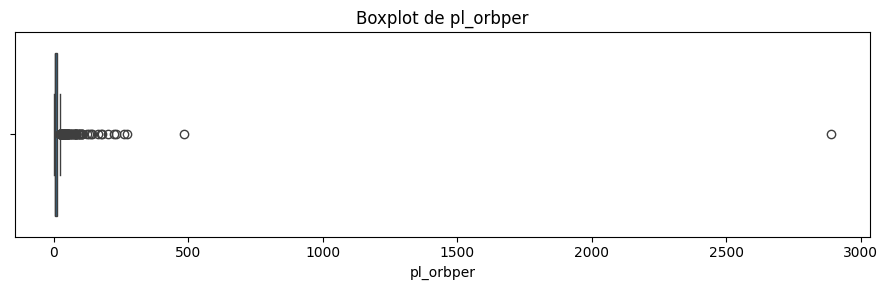

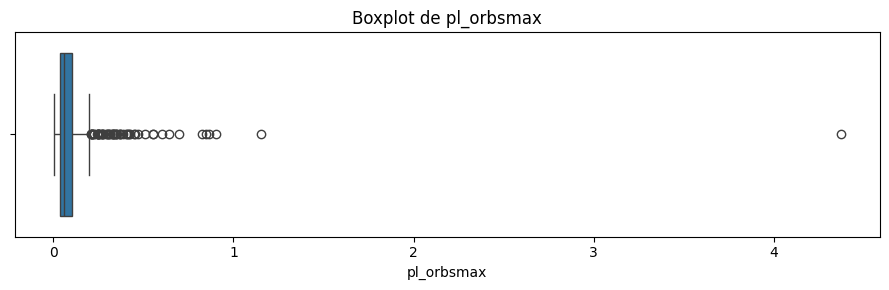

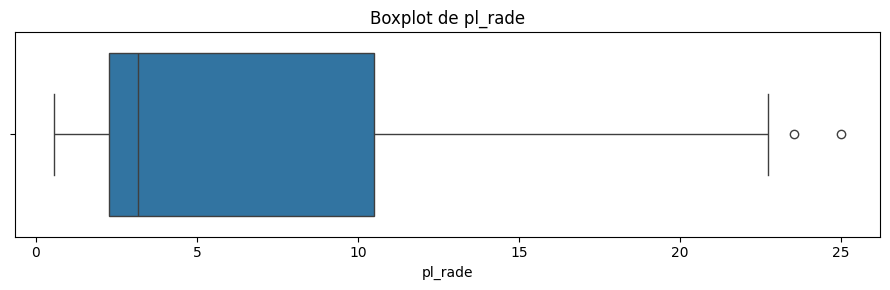

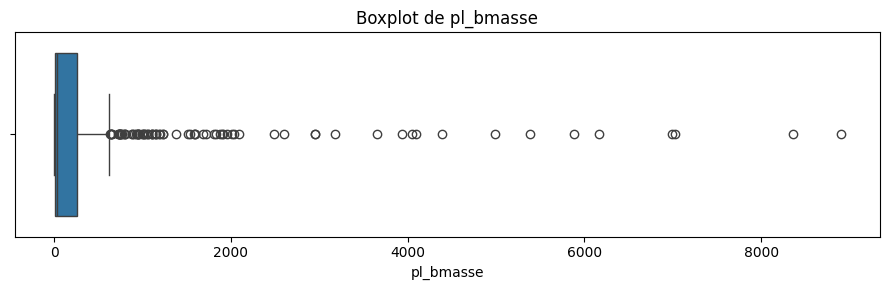

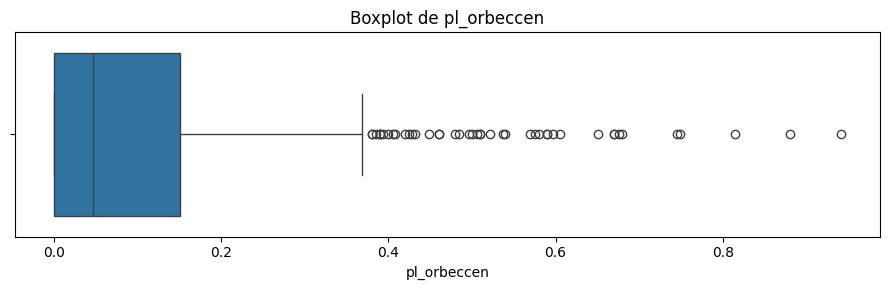

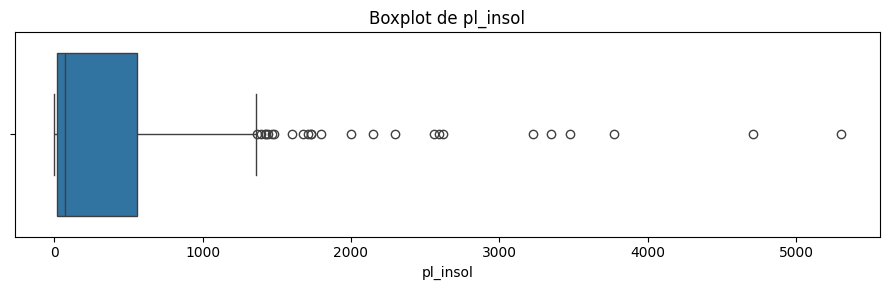

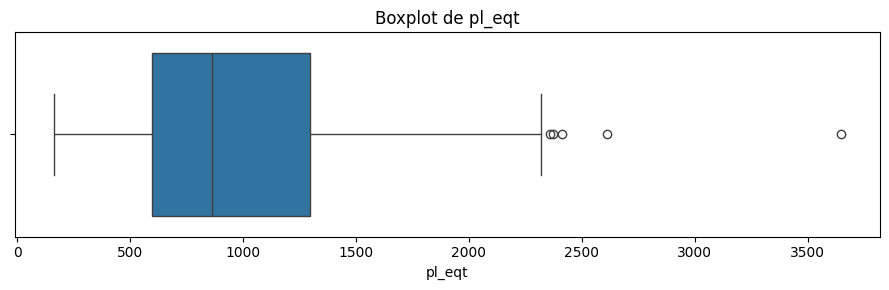

In [27]:
# Recorremos las variables planetarias para visualizar
# individualmente su dispersión y posibles valores extremos.
for feature in planet_features:

    # Creamos una figura independiente para cada variable.
    plt.figure(figsize=(9, 3))

    # Generamos el boxplot utilizando únicamente
    # los valores disponibles de la variable.
    sns.boxplot(
        x=df[feature].dropna()
    )

    # Añadimos un título descriptivo.
    plt.title(
        f"Boxplot de {feature}"
    )

    # Etiquetamos el eje horizontal.
    plt.xlabel(feature)

    # Ajustamos el diseño.
    plt.tight_layout()

    # Mostramos el gráfico.
    plt.show()

### 6.1 Interpretación de la asimetría y los valores extremos

El análisis cuantitativo confirma que todas las variables planetarias presentan algún grado de asimetría positiva, aunque con intensidades muy diferentes.

Las mayores asimetrías aparecen en `pl_orbper` y `pl_orbsmax`, con coeficientes de skewness de aproximadamente 26,28 y 15,26 respectivamente. Estos valores reflejan una fuerte concentración de observaciones en rangos bajos y la existencia de una cola muy extensa hacia valores superiores.

`pl_bmasse`, `pl_insol` y `pl_orbeccen` también presentan asimetrías elevadas, mientras que `pl_rade` y especialmente `pl_eqt` muestran distribuciones menos extremas.

Los boxplots identifican numerosos valores estadísticamente atípicos en varias características. Sin embargo, estos valores no se eliminarán automáticamente.

En un contexto astrofísico, una observación alejada del rango central puede representar un planeta con características físicas poco frecuentes y no necesariamente un error de medición. Eliminar estos objetos sin analizarlos podría reducir artificialmente la diversidad del dataset y afectar precisamente a la identificación de grupos minoritarios mediante clustering.

Por este motivo, los valores extremos se analizarán cuantitativamente y su tratamiento se decidirá posteriormente en función de su naturaleza, distribución y efecto sobre los algoritmos de clustering.

### 6.2 Identificación cuantitativa mediante el método IQR

Para cuantificar la presencia de valores potencialmente atípicos se utiliza el método del rango intercuartílico (IQR).

El IQR se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

`IQR = Q3 - Q1`

De forma convencional, se consideran potencialmente atípicos los valores situados fuera del intervalo:

- Límite inferior: `Q1 - 1,5 × IQR`
- Límite superior: `Q3 + 1,5 × IQR`

Este criterio se utilizará únicamente como herramienta descriptiva. Las observaciones detectadas no serán eliminadas automáticamente, ya que pueden representar exoplanetas físicamente válidos con características poco frecuentes.

In [28]:
# Creamos una lista vacía donde almacenaremos
# los resultados del análisis de cada variable.
outlier_summary = []

# Analizamos individualmente cada variable planetaria.
for feature in planet_features:

    # Eliminamos temporalmente los valores nulos únicamente
    # para poder calcular correctamente los cuartiles.
    data = df[feature].dropna()

    # Calculamos el primer y tercer cuartil.
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    # Calculamos el rango intercuartílico (IQR),
    # que contiene el 50 % central de los datos.
    iqr = q3 - q1

    # Calculamos los límites convencionales utilizados
    # para identificar posibles valores atípicos.
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    # Identificamos qué observaciones se encuentran
    # fuera de los límites calculados.
    outliers = data[
        (data < lower_limit) |
        (data > upper_limit)
    ]

    # Calculamos qué porcentaje representan respecto
    # a los valores disponibles de esa variable.
    outlier_percentage = (
        len(outliers) / len(data)
    ) * 100

    # Guardamos los resultados para construir
    # posteriormente una tabla resumen.
    outlier_summary.append({
        "variable": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": lower_limit,
        "limite_superior": upper_limit,
        "n_outliers_IQR": len(outliers),
        "porcentaje_outliers": round(
            outlier_percentage, 2
        )
    })

# Convertimos los resultados en un DataFrame
# para facilitar su interpretación.
outlier_summary_df = pd.DataFrame(
    outlier_summary
)

outlier_summary_df

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers_IQR,porcentaje_outliers
0,pl_orbper,3.347239,11.514239,8.167001,-8.903262,23.764741,97,10.69
1,pl_orbsmax,0.037950,0.105550,0.067600,-0.063450,0.206950,59,8.38
2,pl_rade,2.265000,10.500000,8.235000,-10.087500,22.852500,2,0.22
3,pl_bmasse,7.700000,255.851868,248.151868,-364.527801,628.079669,78,12.58
4,pl_orbeccen,0.000000,0.150000,0.150000,-0.225000,0.375000,44,7.06
5,pl_insol,18.670750,557.000000,538.329250,-788.823125,1364.493875,25,6.48
6,pl_eqt,596.000000,1294.250000,698.250000,-451.375000,2341.625000,5,0.75


### 6.3 Conclusiones sobre los valores potencialmente atípicos

La aplicación del criterio IQR muestra diferencias importantes entre las variables planetarias.

`pl_bmasse` y `pl_orbper` presentan las mayores proporciones de observaciones clasificadas como potencialmente atípicas, con aproximadamente un 12,58 % y un 10,69 % respectivamente. También se identifican porcentajes relevantes en `pl_orbsmax`, `pl_orbeccen` y `pl_insol`.

Estos resultados son coherentes con las fuertes asimetrías observadas previamente en sus distribuciones.

Por el contrario, `pl_rade` y `pl_eqt` presentan porcentajes muy reducidos de valores fuera de los límites establecidos por el criterio IQR.

No se eliminarán automáticamente las observaciones identificadas como atípicas.

El método IQR identifica valores estadísticamente alejados del rango central de una distribución, pero no permite determinar por sí mismo si dichos valores son errores. En un dataset de exoplanetas, algunos de estos casos pueden corresponder a objetos reales con propiedades físicas poco frecuentes.

Además, eliminar estos valores podría reducir artificialmente la diversidad del dataset y eliminar posibles grupos minoritarios que podrían resultar relevantes para el clustering.

Por tanto, se conservarán inicialmente estas observaciones y se estudiará posteriormente el uso de transformaciones y técnicas de escalado adecuadas para reducir la influencia desproporcionada de las distribuciones extremas sobre las métricas de distancia.

## 7. Análisis de las variables estelares

Además de las propiedades directamente relacionadas con los exoplanetas, el conjunto inicial de características candidatas incluye información sobre sus estrellas anfitrionas.

Las propiedades de la estrella pueden aportar contexto relevante sobre el entorno en el que se encuentra cada planeta.

Las variables analizadas son:

- `st_teff`: temperatura efectiva de la estrella.
- `st_rad`: radio estelar.
- `st_mass`: masa estelar.
- `st_met`: metalicidad.
- `st_logg`: gravedad superficial.

Se analizarán sus distribuciones, asimetría y presencia de valores extremos siguiendo los mismos criterios utilizados anteriormente para las variables planetarias.

Posteriormente se estudiarán las relaciones entre todas las características candidatas para determinar si algunas variables contienen información redundante.

In [29]:
# Calculamos los principales estadísticos descriptivos
# de las variables relacionadas con la estrella anfitriona.
stellar_descriptive = df[stellar_features].describe().T

# Añadimos explícitamente la mediana para poder compararla
# fácilmente con la media de cada característica.
stellar_descriptive["median"] = (
    df[stellar_features].median()
)

# Seleccionamos los estadísticos más relevantes
# para el análisis exploratorio.
stellar_descriptive = stellar_descriptive[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

stellar_descriptive

,count,mean,median,std,min,25%,50%,75%,max
st_teff,885.0,5053.029266,5315.0000,1019.216501,2850.0000,4201.930,5315.0000,5823.0000,8500.000
st_rad,905.0,0.964791,0.8660,0.510088,0.0131,0.657,0.8660,1.2000,4.100
st_mass,787.0,0.866176,0.8889,0.339001,0.1180,0.630,0.8889,1.1000,1.900
st_met,685.0,0.054527,0.0600,0.201011,-0.6600,-0.070,0.0600,0.1900,0.790
st_logg,821.0,4.470500,4.4870,0.310413,3.2440,4.290,4.4870,4.6361,7.915


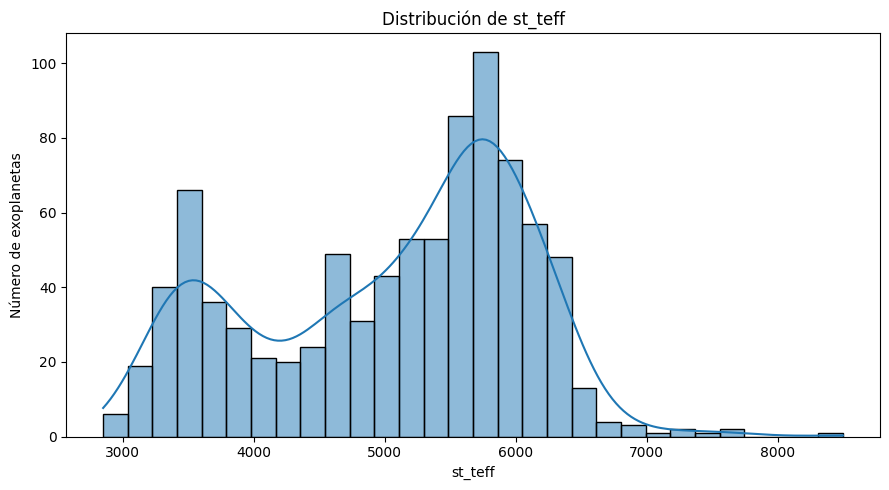

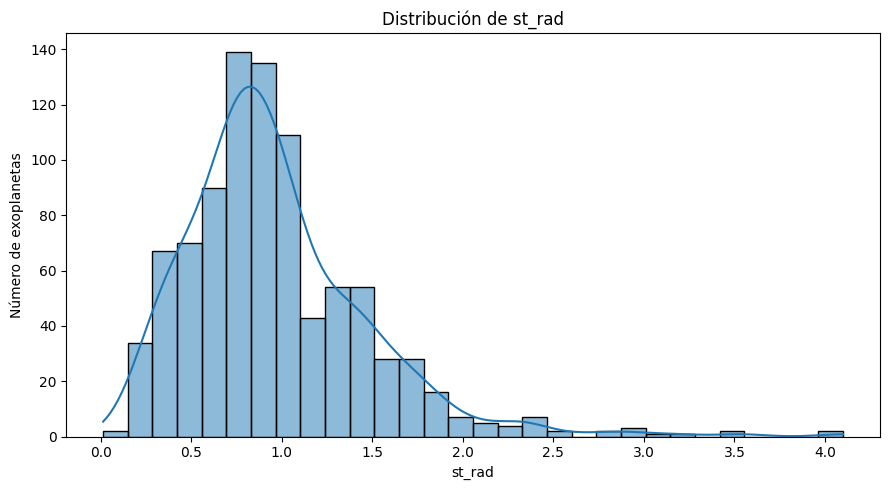

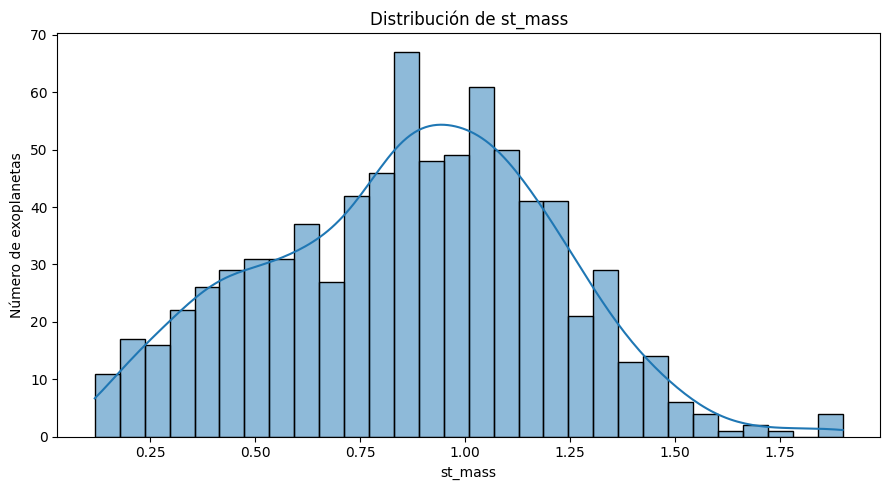

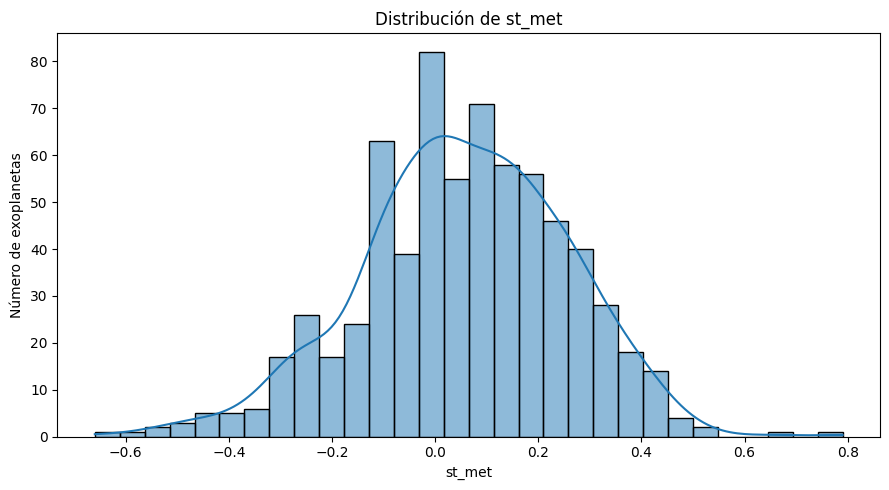

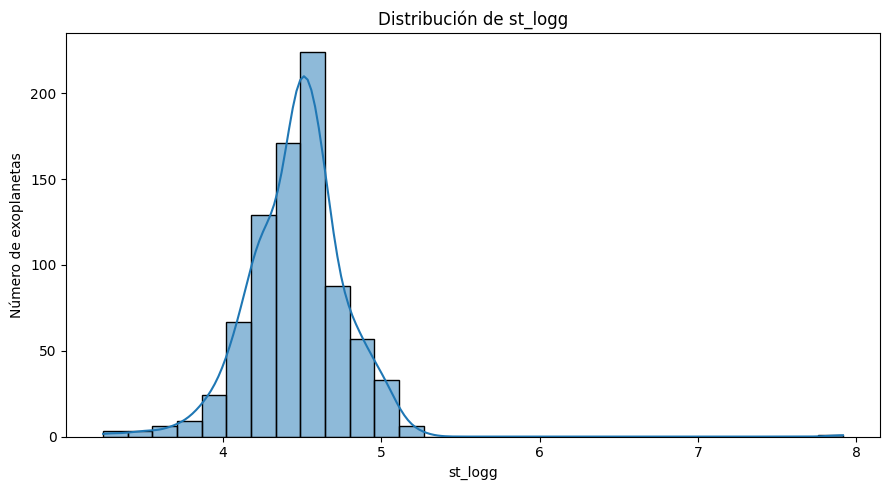

In [30]:
# Recorremos cada variable estelar para analizar
# visualmente la forma de su distribución.
for feature in stellar_features:

    # Creamos una figura independiente para cada variable.
    plt.figure(figsize=(9, 5))

    # Eliminamos únicamente los valores nulos de la variable
    # representada, sin modificar el DataFrame original.
    data = df[feature].dropna()

    # Creamos el histograma y añadimos una estimación
    # suavizada de la densidad mediante KDE.
    sns.histplot(
        data=data,
        bins=30,
        kde=True
    )

    # Añadimos títulos y etiquetas descriptivas.
    plt.title(f"Distribución de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Número de exoplanetas")

    # Ajustamos y mostramos el gráfico.
    plt.tight_layout()
    plt.show()

In [31]:
# Calculamos el coeficiente de asimetría
# de cada variable estelar.
stellar_skewness = (
    df[stellar_features]
    .skew()
    .sort_values(ascending=False)
)

# Convertimos el resultado en una tabla
# para facilitar su interpretación.
stellar_skewness_df = stellar_skewness.to_frame(
    name="skewness"
)

stellar_skewness_df

,skewness
st_rad,1.645483
st_logg,1.314813
st_mass,-0.037888
st_met,-0.238448
st_teff,-0.359925


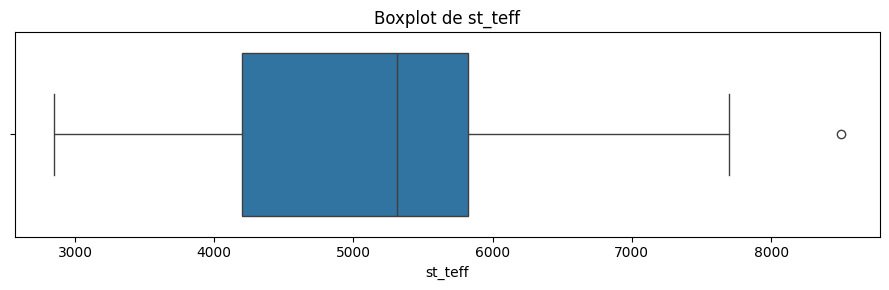

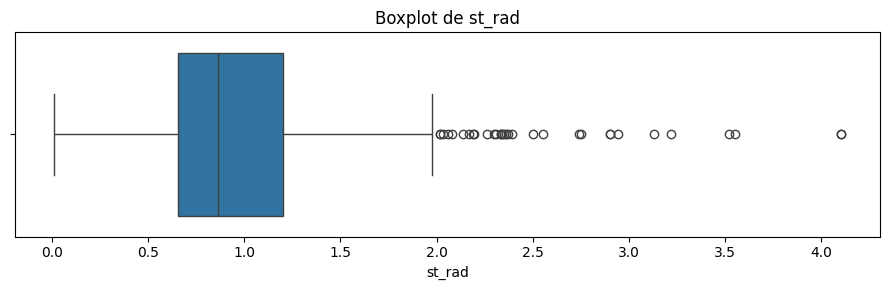

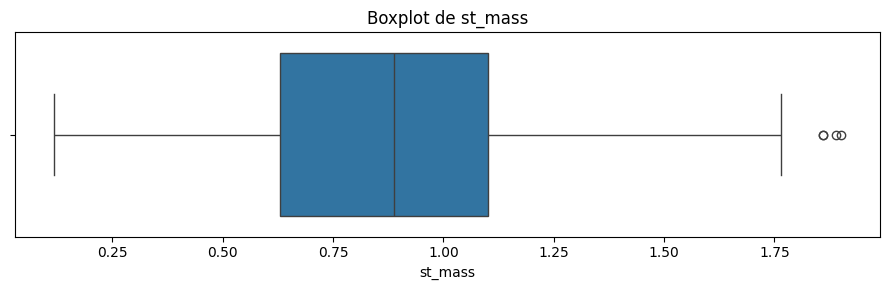

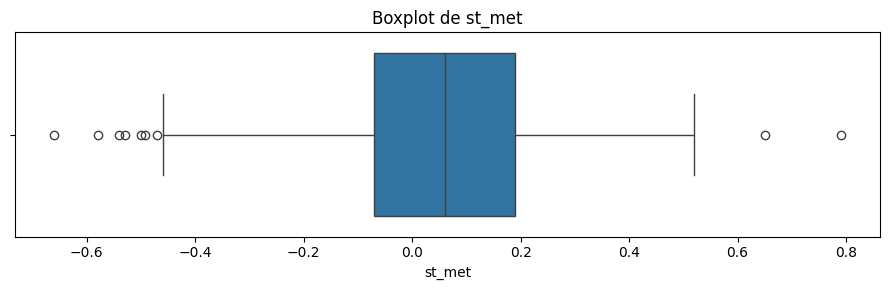

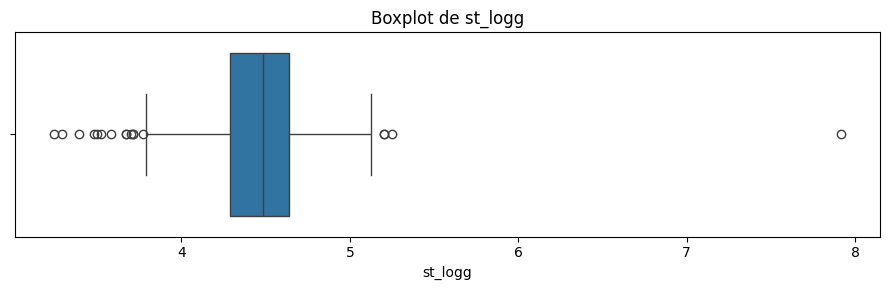

In [32]:
# Creamos un boxplot independiente para cada
# variable estelar con el objetivo de estudiar
# su dispersión y posibles valores extremos.
for feature in stellar_features:

    plt.figure(figsize=(9, 3))

    # Los valores nulos se excluyen únicamente
    # para construir correctamente el gráfico.
    sns.boxplot(
        x=df[feature].dropna()
    )

    plt.title(f"Boxplot de {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

### 7.1 Inspección de valores extremos destacados

La inspección visual de las variables estelares muestra un valor especialmente alejado del resto de observaciones en `st_logg`.

A diferencia de otras variables donde existe una cola progresiva de valores elevados, este caso aparece claramente aislado respecto a la distribución principal.

Antes de decidir cualquier tratamiento, se inspeccionará la observación correspondiente y el resto de sus características para determinar si existen indicios de un posible valor anómalo o si puede tratarse de una observación físicamente válida.

### 7.2 Interpretación inicial de las variables estelares

Las variables relacionadas con las estrellas anfitrionas presentan, en general, distribuciones menos extremas que las observadas en varias características planetarias.

`st_mass`, `st_met` y `st_teff` muestran coeficientes de asimetría relativamente próximos a cero, especialmente `st_mass`, cuya media y mediana son también muy similares.

`st_rad` presenta una asimetría positiva más marcada y una cola formada por estrellas de mayor tamaño. Estos valores no se consideran automáticamente errores, ya que pueden corresponder a diferencias físicas reales entre las estrellas anfitrionas.

La distribución de `st_teff` muestra distintas concentraciones de observaciones en determinados rangos de temperatura, un patrón que podría resultar relevante al estudiar posteriormente la estructura conjunta de los datos.

En `st_logg` se observa un valor especialmente alejado de la distribución principal. Debido a su carácter aislado, esta observación será inspeccionada individualmente antes de decidir cualquier posible tratamiento.

En conjunto, las variables estelares presentan distribuciones estadísticamente más moderadas que algunas características planetarias. No obstante, su utilidad final para el clustering dependerá también de su cobertura, sus relaciones con otras variables y la posible existencia de información redundante.

In [33]:
# Localizamos las observaciones con los valores más altos
# de gravedad superficial estelar (st_logg).
#
# No eliminamos ningún registro: únicamente inspeccionamos
# los casos extremos para comprender mejor su contexto.
df.nlargest(
    5,
    "st_logg"
)[
    [
        "pl_name",
        "st_logg",
        "st_mass",
        "st_rad",
        "st_teff"
    ]
]

,pl_name,st_logg,st_mass,st_rad,st_teff
907,WD 1856+534 b,7.915,0.518,0.0131,4710.0
15,Gliese 12 b,5.250,0.255,0.2650,3328.0
56,HD 260655 b,5.200,0.439,0.4390,3803.0
57,HD 260655 c,5.200,0.439,0.4390,3803.0
109,LP 890-9 b,5.126,0.118,0.1556,2850.0


#### Análisis del valor extremo de `st_logg`

La inspección individual de las observaciones con mayor gravedad superficial muestra que el valor máximo de `st_logg` (7,915) corresponde al sistema **WD 1856+534 b**.

Este registro presenta también un radio estelar (`st_rad = 0,0131`) extremadamente reducido en comparación con el resto de la muestra.

La estrella anfitriona de este sistema es una enana blanca, un tipo de remanente estelar caracterizado por concentrar una masa considerable en un radio muy pequeño. Por tanto, una gravedad superficial elevada resulta físicamente coherente con sus características.

Este caso demuestra que un valor estadísticamente extremo no debe considerarse automáticamente un error.

Por este motivo, la observación no será eliminada del dataset. La decisión sobre si `st_logg` debe formar parte de las variables utilizadas para clustering se realizará posteriormente en función de su utilidad, cobertura y relación con otras características.